# US -Adult Income

**Packages essentiels**

In [73]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(rc={'figure.figsize':(9,6)})

**Data Loading**

In [74]:
train_path = "train.csv"
test_path = "test.csv"
traindf = pd.read_csv(train_path, header=0)
testdf = pd.read_csv(test_path)
features = traindf.columns

**Apperçu de la dataset**

In [75]:
traindf.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [76]:
df = traindf.copy()

## Exploratory Data Analysis

**Data understanding**

**Information initiales : nombre d'enregistrement, types d'attributs..**

In [77]:
print(f'Volum de la dataset : {df.shape}')

Volum de la dataset : (32561, 15)


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1   workclass        32561 non-null  object
 2   fnlwgt           32561 non-null  int64 
 3   education        32561 non-null  object
 4   educational-num  32561 non-null  int64 
 5   marital-status   32561 non-null  object
 6   occupation       32561 non-null  object
 7   relationship     32561 non-null  object
 8   race             32561 non-null  object
 9   gender           32561 non-null  object
 10  capital-gain     32561 non-null  int64 
 11  capital-loss     32561 non-null  int64 
 12  hours-per-week   32561 non-null  int64 
 13  native-country   32561 non-null  object
 14  income           32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


**Statistiques descriptives**

In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
educational-num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


Distribution des classes :
income
 <=50K    24720
 >50K      7841
dtype: int64


Text(0.5, 1.0, 'income')

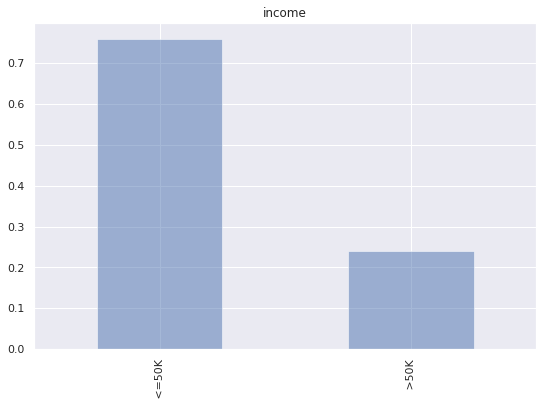

In [80]:
print('Distribution des classes :')
print(df.groupby('income').size())
df.income.value_counts(normalize=True).plot(kind='bar', alpha=0.5)
plt.title('income')

**On remarque une difference dans la distribution des deux classes, c'est le cas : 'unbalanced dataset'**

In [81]:
cat_df = df.select_dtypes(include=['object'])
print('Number of categorical variables : ',len(cat_df.columns))

num_df = df[[c for c in df if c not in cat_df.columns]]
print('Number of numerical variables : ',len(num_df.columns))

Number of categorical variables :  9
Number of numerical variables :  6


**Visualisations**

**Histogrammes des features numériques**

/home/haddadi/anaconda3/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:298: MatplotlibDeprecationWarning:


The rowNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().rowspan.start instead.

/home/haddadi/anaconda3/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:298: MatplotlibDeprecationWarning:


The colNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().colspan.start instead.

/home/haddadi/anaconda3/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:304: MatplotlibDeprecationWarning:


The rowNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().rowspan.start instead.

/home/haddadi/anaconda3/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:304: MatplotlibDeprecationWarning:


The colNum attribute was deprecated in Matplotlib

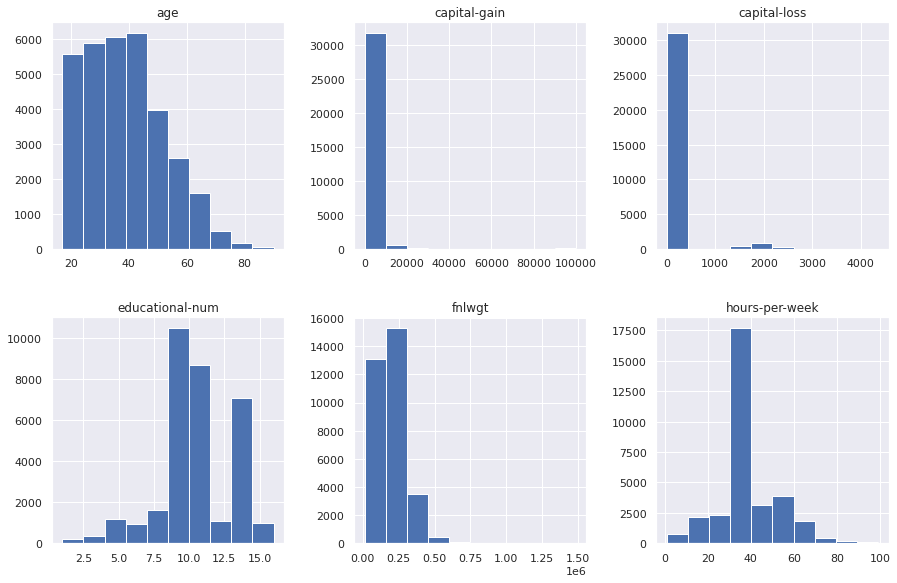

In [82]:
df.hist(figsize=(15,15), layout=(3,3), sharex=False);

**Distribution des attributs numériques**

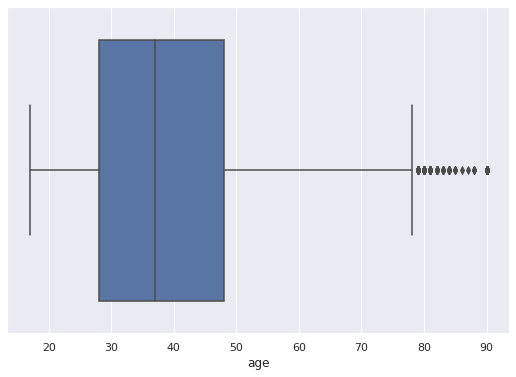

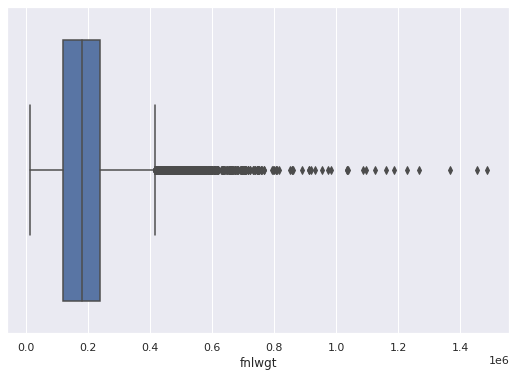

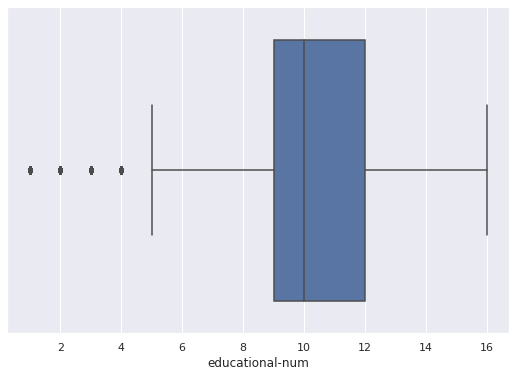

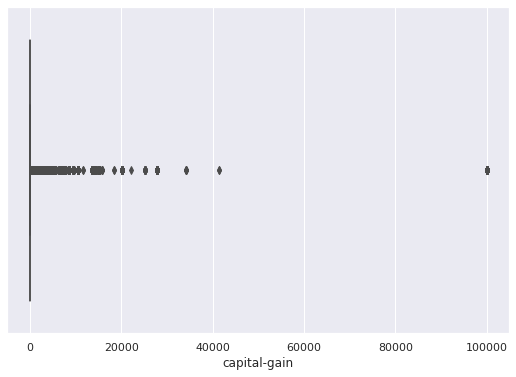

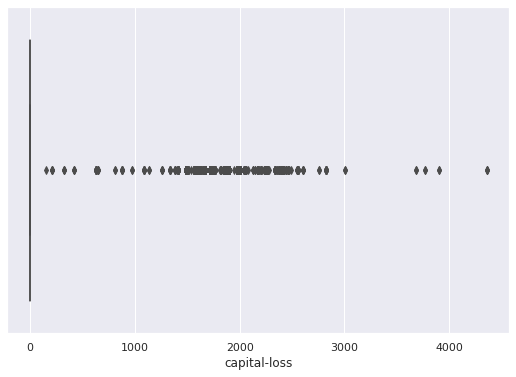

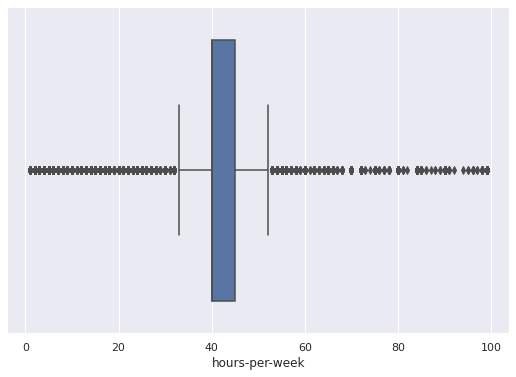

In [83]:
for i, col in enumerate(num_df):
    plt.figure(i)
    sns.boxplot(x=df[col])

**Gender & Income**

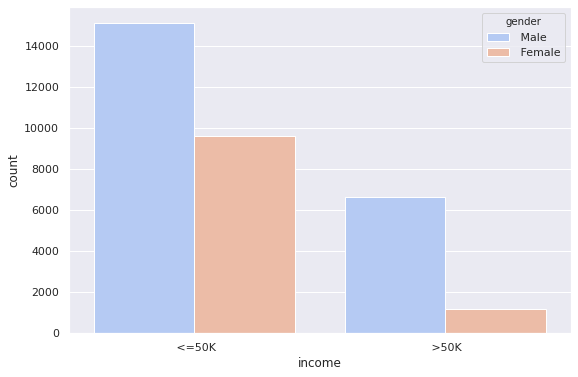

In [84]:
sns.countplot(df['income'], palette='coolwarm', hue='gender', data=df);

**Race & Income**

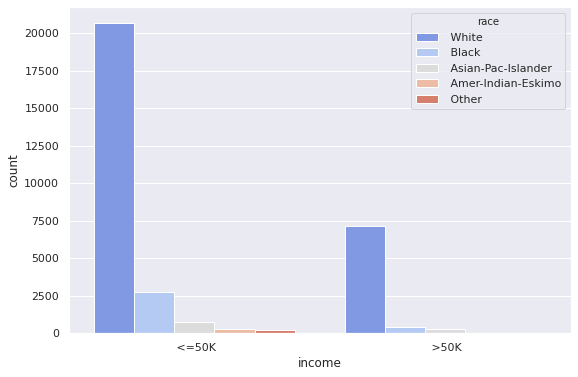

In [85]:
sns.countplot(df['income'], palette='coolwarm', hue='race', data=df);

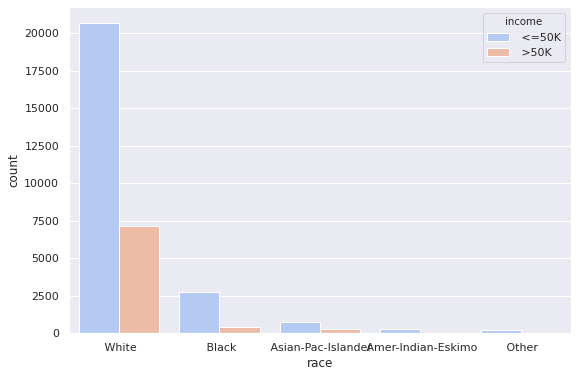

In [86]:
sns.countplot(df['race'], palette='coolwarm', hue='income', data=df);

**Marital-Status & Income**

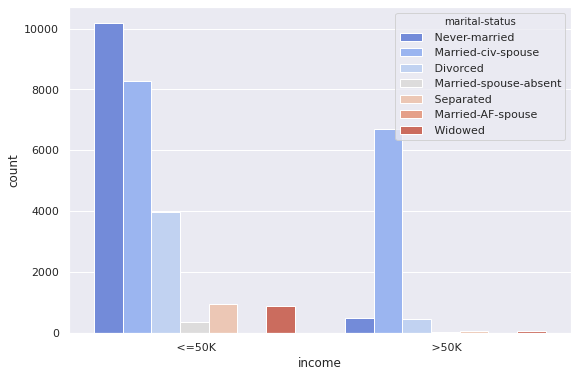

In [87]:
sns.countplot(df['income'], palette='coolwarm', hue='marital-status', data=df);

**Relationship & Income**

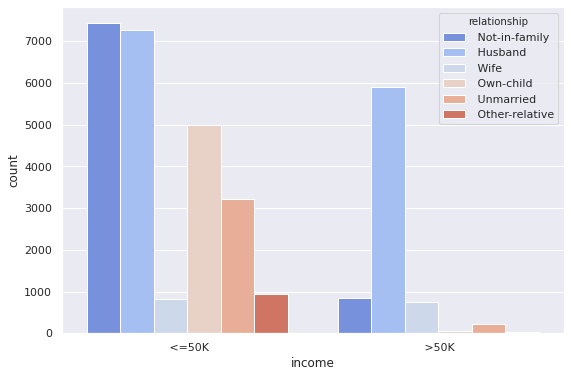

In [88]:
sns.countplot(df['income'], palette='coolwarm', hue='relationship', data=df);

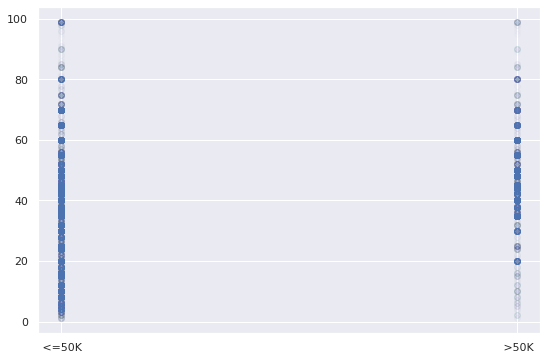

In [89]:
plt.scatter(df['income'], df['hours-per-week'],alpha=0.01)

**Capital-gain & capital-loss**

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f2b1661a490>,
      dtype=object)

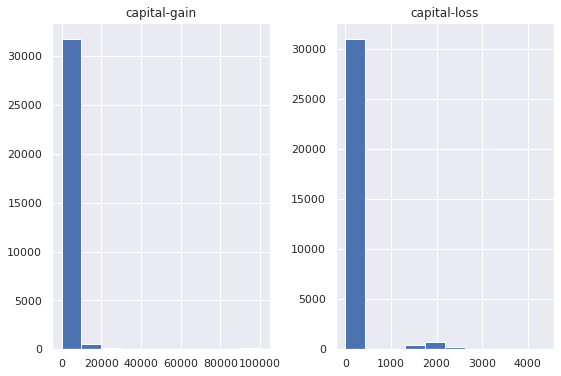

In [90]:
traindf.hist(column = ["capital-gain", "capital-loss"])

**Feature engineering**

In [91]:
df.loc[(df['hours-per-week'] < 40),'hours-per-week'] = 0
df.loc[(df['hours-per-week'] >= 40) & (df['hours-per-week']<=60),'hours-per-week'] = 1
df.loc[(df['hours-per-week'] > 60),'hours-per-week'] = 2

df['hours-per-week'].value_counts()

1    23688
0     7763
2     1110
Name: hours-per-week, dtype: int64

In [92]:
px.pie(df, names='hours-per-week', title='% of hours rate', 
      color_discrete_sequence = px.colors.qualitative.T10)
# 0 : < 40 hour/week
# 1 : 40 < < 60 
# 2 : > 60 hour/week

In [93]:
px.pie(df, values='educational-num', names='education', title='% of edu', 
      color_discrete_sequence = px.colors.qualitative.T10)

**Detection des valeurs manquantes**

In [94]:
df['workclass'].value_counts()

 Private             22696
 Self-emp-not-inc     2541
 Local-gov            2093
 ?                    1836
 State-gov            1298
 Self-emp-inc         1116
 Federal-gov           960
 Without-pay            14
 Never-worked            7
Name: workclass, dtype: int64

In [95]:
df['marital-status'].value_counts()

 Married-civ-spouse       14976
 Never-married            10683
 Divorced                  4443
 Separated                 1025
 Widowed                    993
 Married-spouse-absent      418
 Married-AF-spouse           23
Name: marital-status, dtype: int64

In [96]:
df['occupation'].value_counts()

 Prof-specialty       4140
 Craft-repair         4099
 Exec-managerial      4066
 Adm-clerical         3770
 Sales                3650
 Other-service        3295
 Machine-op-inspct    2002
 ?                    1843
 Transport-moving     1597
 Handlers-cleaners    1370
 Farming-fishing       994
 Tech-support          928
 Protective-serv       649
 Priv-house-serv       149
 Armed-Forces            9
Name: occupation, dtype: int64

In [97]:
df.loc[df['occupation']==' ?','occupation'] = df['occupation'].value_counts().idxmax()
df.loc[df['workclass']==' ?','workclass'] = df['workclass'].value_counts().idxmax()
df.loc[df['native-country']==' ?','native-country'] = df['native-country'].value_counts().idxmax()

In [98]:
df['workclass'].value_counts()

 Private             24532
 Self-emp-not-inc     2541
 Local-gov            2093
 State-gov            1298
 Self-emp-inc         1116
 Federal-gov           960
 Without-pay            14
 Never-worked            7
Name: workclass, dtype: int64

**Detection des valeurs aberantes - Outliers**

In [99]:
from collections import Counter
def findOutliers_With_Tukey_Method(df, n, features):   
    Outliers_indicies = []
    for feature in features:
        Q1 = np.percentile(df[feature], 25)
        Q3 = np.percentile(df[feature], 75)
        IQR = Q3-Q1
        
        outlierStep = IQR *1.5
        
        outlier_indexes_for_feature = df[( df[feature] < Q1-outlierStep ) | (df[feature] > Q3 + outlierStep)  ].index
        Outliers_indicies.extend(outlier_indexes_for_feature)
        
    Outliers_indicies = Counter(Outliers_indicies)        
    multiple_outliers = list( k for k, v in Outliers_indicies.items() if v > n )
    return multiple_outliers

In [100]:
outliers_to_drop = findOutliers_With_Tukey_Method(df, 2, num_df.columns)
df.loc[outliers_to_drop]

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
2754,80,Self-emp-not-inc,184335,7th-8th,4,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,0,United-States,<=50K
2906,81,Private,114670,9th,5,Widowed,Priv-house-serv,Not-in-family,Black,Female,2062,0,0,United-States,<=50K
3211,82,Private,29441,7th-8th,4,Widowed,Prof-specialty,Not-in-family,White,Male,0,0,0,United-States,<=50K
4109,90,Private,256514,Bachelors,13,Widowed,Prof-specialty,Other-relative,White,Female,991,0,0,United-States,<=50K
6173,79,Private,120707,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,20051,0,0,El-Salvador,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25569,59,Self-emp-not-inc,144071,5th-6th,3,Married-civ-spouse,Other-service,Husband,White,Male,2580,0,0,El-Salvador,<=50K
26995,33,Private,228696,1st-4th,2,Married-civ-spouse,Craft-repair,Not-in-family,White,Male,0,2603,0,Mexico,<=50K
27164,50,Private,95435,7th-8th,4,Married-civ-spouse,Transport-moving,Husband,White,Male,0,1579,2,Canada,<=50K
28207,78,Private,184759,7th-8th,4,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,1797,0,0,United-States,<=50K


**Drop the outliers since they are just 89 rows**

In [101]:
df.drop(outliers_to_drop, axis=0).reset_index(drop=True)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,1,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,1,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,1,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,1,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32467,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,0,United-States,<=50K
32468,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,1,United-States,>50K
32469,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,1,United-States,<=50K
32470,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,0,United-States,<=50K


**Categorical Variables**

In [102]:
def ConvertCategVariables(raw_df, features):
    df = raw_df.copy()
    for f in features:
        df[f] = df[f].astype('category')
        new_feature_name = f+'_encoded'
        df[new_feature_name] = df[f].cat.codes
        del df[f]
    
    return df

In [103]:
df = ConvertCategVariables(df, ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender'])
df.head(15)

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,native-country,income,workclass_encoded,education_encoded,marital-status_encoded,occupation_encoded,relationship_encoded,race_encoded,gender_encoded
0,39,77516,13,2174,0,1,United-States,<=50K,6,9,4,0,1,4,1
1,50,83311,13,0,0,0,United-States,<=50K,5,9,2,3,0,4,1
2,38,215646,9,0,0,1,United-States,<=50K,3,11,0,5,1,4,1
3,53,234721,7,0,0,1,United-States,<=50K,3,1,2,5,0,2,1
4,28,338409,13,0,0,1,Cuba,<=50K,3,9,2,9,5,2,0
5,37,284582,14,0,0,1,United-States,<=50K,3,12,2,3,5,4,0
6,49,160187,5,0,0,0,Jamaica,<=50K,3,6,3,7,1,2,0
7,52,209642,9,0,0,1,United-States,>50K,5,11,2,3,0,4,1
8,31,45781,14,14084,0,1,United-States,>50K,3,12,4,9,1,4,0
9,42,159449,13,5178,0,1,United-States,>50K,3,9,2,3,0,4,1


**Traiter la variable 'Native-country'**

**On remarque que 29753 parmis 32561 sont des USA, donc il est possible de classer les autres pays dans une categorie 'Other', puis on transforme l'attribut en format numerique**

In [104]:
df.loc[(df['native-country'] != ' United-States'), 'native-country'] = 'other'
df.loc[(df['native-country'] == ' United-States'), 'native-country'] = 'usa'

df.loc[(df['native-country'] == 'other'), 'native-country'] = int(0)
df.loc[(df['native-country'] == 'usa'), 'native-country'] = int(1)

**Traiter la variable 'Income'**

In [105]:
replace_map = {'income': {'>50K': 0, '<=50K': 1}}

labels = df['income'].astype('category').cat.categories.tolist()
replace_map_comp = {'income' : {k: v for k,v in zip(labels,list(range(0,len(labels)+1)))}}
replace_map_comp
df.replace(replace_map_comp, inplace=True)

**Drop the 'fnlwgt' feature**

In [106]:
df = df.drop(['fnlwgt'], axis=1)
df.head()

,age,educational-num,capital-gain,capital-loss,hours-per-week,native-country,income,workclass_encoded,education_encoded,marital-status_encoded,occupation_encoded,relationship_encoded,race_encoded,gender_encoded
0,39,13,2174,0,1,1,0,6,9,4,0,1,4,1
1,50,13,0,0,0,1,0,5,9,2,3,0,4,1
2,38,9,0,0,1,1,0,3,11,0,5,1,4,1
3,53,7,0,0,1,1,0,3,1,2,5,0,2,1
4,28,13,0,0,1,0,0,3,9,2,9,5,2,0


## Classification 

In [107]:
from sklearn.model_selection import train_test_split, StratifiedKFold,  cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression  
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics


**Creation du train et test dataset**

In [108]:
train, test = train_test_split(df, test_size = 0.2)
print(f'Train Shape : {train.shape} , Test Shape : {test.shape}')

Train Shape : (26048, 14) , Test Shape : (6513, 14)


In [109]:
features = df.columns
features.drop('income')

Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'workclass_encoded',
       'education_encoded', 'marital-status_encoded', 'occupation_encoded',
       'relationship_encoded', 'race_encoded', 'gender_encoded'],
      dtype='object')

In [110]:
y_train = train.income
y_test = test.income
x_train = train[features].drop(['income'], axis=1)
x_test = test[features].drop(['income'], axis=1)

In [111]:
x_train.head()

,age,educational-num,capital-gain,capital-loss,hours-per-week,native-country,workclass_encoded,education_encoded,marital-status_encoded,occupation_encoded,relationship_encoded,race_encoded,gender_encoded
19193,44,13,15024,0,1,1,1,9,2,10,5,2,0
32139,47,15,15024,0,1,1,5,14,2,9,0,4,1
13787,43,13,0,0,1,1,6,9,2,3,0,4,1
29822,47,9,0,0,0,1,1,11,0,0,4,4,0
508,47,9,0,0,1,1,1,11,5,0,4,2,0


**Apprentissage des algorithmes**

In [112]:
kfold = StratifiedKFold(n_splits=10)
random_state = 2
classifiers = []
classifiers.append(KNeighborsClassifier())
classifiers.append(SVC(random_state=random_state))
classifiers.append(DecisionTreeClassifier(random_state=random_state))
classifiers.append(AdaBoostClassifier(DecisionTreeClassifier(random_state=random_state),random_state=random_state,learning_rate=0.1))
classifiers.append(RandomForestClassifier(random_state=random_state))
classifiers.append(ExtraTreesClassifier(random_state=random_state))
classifiers.append(GradientBoostingClassifier(random_state=random_state))
classifiers.append(LogisticRegression(random_state = random_state))

cv_results = []
for classifier in classifiers :
    cv_results.append(cross_val_score(classifier, x_train, y = y_train, scoring = "accuracy", cv = kfold, n_jobs=4))
    print(cross_val_score(classifier, x_train, y = y_train, scoring = "accuracy", cv = kfold, n_jobs=4))
cv_means = []
cv_std = []
for cv_result in cv_results:
    cv_means.append(cv_result.mean())
    cv_std.append(cv_result.std())

cv_res = pd.DataFrame({"CrossValMeans":cv_means,"CrossValerrors": cv_std,"Algorithm":["KNeighbors", "SVC","DecisionTree","AdaBoost",
"RandomForest","ExtraTrees","GradientBoosting", "LogisticRegression"]})


[0.8452975  0.85105566 0.85143954 0.84568138 0.84913628 0.84568138
 0.83800384 0.83953935 0.83717358 0.83486943]
[0.8084453  0.79769674 0.80614203 0.80537428 0.80575816 0.80345489
 0.79846449 0.79539347 0.79877112 0.79147465]
[0.81957774 0.80767754 0.81957774 0.81804223 0.82149712 0.81957774
 0.82034549 0.81266795 0.81835637 0.81336406]
[0.8168906  0.80076775 0.81573896 0.80115163 0.80729367 0.80882917
 0.80268714 0.80882917 0.80568356 0.80990783]
[0.84568138 0.83685221 0.8452975  0.84452975 0.84414587 0.84606526
 0.83608445 0.84069098 0.84139785 0.84408602]
[0.82994242 0.82725528 0.83877159 0.83493282 0.83915547 0.83071017
 0.82456814 0.8318618  0.83064516 0.83064516]
[0.86026871 0.86142035 0.86487524 0.86602687 0.86679463 0.86833013
 0.85834933 0.85642994 0.87365591 0.86482335]
[0.80652591 0.80345489 0.81305182 0.81036468 0.80921305 0.80460653
 0.78963532 0.79347409 0.80069124 0.79262673]


**Visualison les résultats de l'entrainement des algorithmes**

In [115]:
cv_res

,CrossValMeans,CrossValerrors,Algorithm
0,0.843788,0.005694,KNeighbors
1,0.801098,0.005235,SVC
2,0.817068,0.004161,DecisionTree
3,0.807778,0.005261,AdaBoost
4,0.842483,0.003428,RandomForest
5,0.831849,0.004390,ExtraTrees
6,0.864097,0.004848,GradientBoosting
7,0.802364,0.007664,LogisticRegression


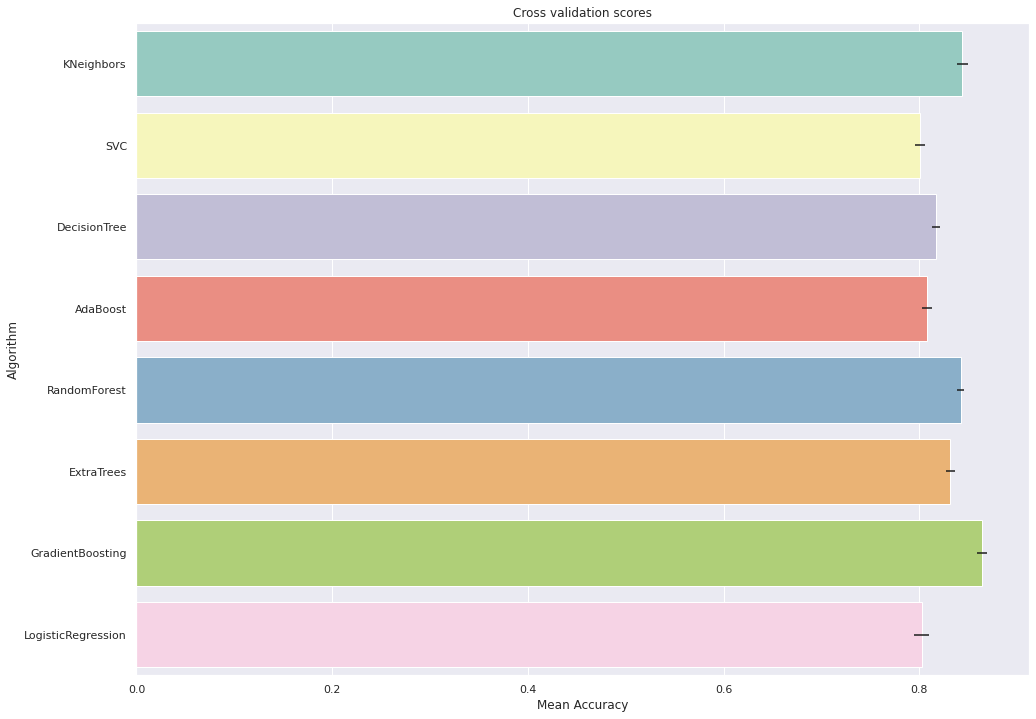

In [116]:
plt.figure(figsize=(16,12))
g = sns.barplot("CrossValMeans","Algorithm",data = cv_res, palette="Set3",orient = "h",**{'xerr':cv_std})
g.set_xlabel("Mean Accuracy")
g = g.set_title("Cross validation scores")

**HyperPaarameters tunning - GridSearchCV**

In [ ]:
GBC = GradientBoostingClassifier() 
gb_param_grid = {'loss' : ["deviance"],
              'n_estimators' : [100,200,300],
              'learning_rate': [0.1, 0.05, 0.01],
              'max_depth': [4, 8,],
              'min_samples_leaf': [100,150],
              'max_features': [0.3, 0.1] 
              }

gsGBC = GridSearchCV(GBC,param_grid = gb_param_grid, cv=kfold, scoring="accuracy", n_jobs=4 , verbose = 1)

gsGBC.fit(x_train,y_train)

GBC_best = gsGBC.best_estimator_

# Best score
gsGBC.best_score_

In [ ]:
RFC = RandomForestClassifier()


## Search grid for optimal parameters
rf_param_grid = {"max_depth": [None],
              "max_features": [1, 3, 10],
              "min_samples_split": [2, 3, 10],
              "min_samples_leaf": [1, 3, 10],
              "bootstrap": [False],
              "n_estimators" :[100,300],
              "criterion": ["gini"]}


gsRFC = GridSearchCV(RFC,param_grid = rf_param_grid, cv=kfold, scoring="accuracy", n_jobs= 4, verbose = 1)

gsRFC.fit(x_train,y_train)

RFC_best = gsRFC.best_estimator_

# Best score
gsRFC.best_score_

In [ ]:
ExtC = ExtraTreesClassifier()


## Search grid for optimal parameters
ex_param_grid = {"max_depth": [None],
              "max_features": [1, 3, 10],
              "min_samples_split": [2, 3, 10],
              "min_samples_leaf": [1, 3, 10],
              "bootstrap": [False],
              "n_estimators" :[100,300],
              "criterion": ["gini"]}


gsExtC = GridSearchCV(ExtC,param_grid = ex_param_grid, cv=kfold, scoring="accuracy", n_jobs=4, verbose = 1)

gsExtC.fit(x_train,y_train)

ExtC_best = gsExtC.best_estimator_

# Best score
gsExtC.best_score_

**Enfin pour classifier un element de la TestSet, on va utiliser la technique du  vote entre les 3 algorithms qu'on vient de choisir** 

In [ ]:
votingClf = VotingClassifier(estimators=[('gradientBoost', GBC_best), ('RandomForest',RFC_best), ('ExtraTrees',ExtC_best)], voting='soft', n_jobs=4)
votingClf = votingClf.fit(x_train, y_train)

**Le meme traitement qu'on a realise pour la trainset, on doit le reproduire pour la testset**

In [62]:
testdf.loc[(testdf['hours-per-week'] < 40),'hours-per-week'] = 0
testdf.loc[(testdf['hours-per-week'] >= 40) & (testdf['hours-per-week']<=60),'hours-per-week'] = 1
testdf.loc[(testdf['hours-per-week'] > 60),'hours-per-week'] = 2

testdf.loc[testdf['occupation']==' ?','occupation'] = testdf['occupation'].value_counts().idxmax()
testdf.loc[testdf['workclass']==' ?','workclass'] = testdf['workclass'].value_counts().idxmax()
testdf.loc[testdf['native-country']==' ?','native-country'] = testdf['native-country'].value_counts().idxmax()

outliers_to_dropfortest = findOutliers_With_Tukey_Method(testdf, 2, num_df.columns)
testdf.drop(outliers_to_dropfortest, axis=0).reset_index(drop=True)

testdf = ConvertCategVariables(testdf, ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender'])

testdf.loc[(testdf['native-country'] != ' United-States'), 'native-country'] = 'other'
testdf.loc[(testdf['native-country'] == ' United-States'), 'native-country'] = 'usa'

testdf.loc[(testdf['native-country'] == 'other'), 'native-country'] = int(0)
testdf.loc[(testdf['native-country'] == 'usa'), 'native-country'] = int(1)

replace_map = {'income': {'>50K': 0, '<=50K': 1}}
labels = testdf['income'].astype('category').cat.categories.tolist()
replace_map_comp = {'income' : {k: v for k,v in zip(labels,list(range(0,len(labels)+1)))}}
testdf.replace(replace_map_comp, inplace=True)

testdf = testdf.drop(['fnlwgt'], axis=1)



In [ ]:
testdf.head(10)

In [63]:
Y = testdf.income
X = testdf.drop(['income'], axis=1)

In [64]:
pred = pd.Series(votingClf.predict(X), name="y")

print(accuracy_score(Y, pred))
print(confusion_matrix(Y, pred))
print(classification_report(Y, pred))

NameError: name 'votingClf' is not defined

In [ ]:
cfmat = confusion_matrix(Y, pred)
print("precision = ", cfmat[0][0]/cfmat[0][0]+cfmat[1][0])

print("recall = ", cfmat[0][0]/cfmat[0][0]+cfmat[0][1])


**Les resultats semblent bon, mais est-ce qu'on peut faire mieux ?**

In [47]:
from xgboost import XGBClassifier
x_train['native-country'] = pd.to_numeric(x_train['native-country'])
x_test['native-country'] = pd.to_numeric(x_test['native-country'])
X['native-country'] = pd.to_numeric(X['native-country'])

In [68]:
XGB = XGBClassifier(learning_rate=0.02, n_estimators=600, objective='binary:logistic',
                    silent=True, nthread=1);
XGB.fit(x_train, y_train);

[17:34:49] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost_1593723605503/work/src/learner.cc:480: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.




In [70]:
y_pred = XGB.predict(x_test)
predictions = [round(value) for value in y_pred]
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 87.36%


**Appliqu'on ceci sur la testset**

In [71]:
y_pred = XGB.predict(X)
predictions = [round(value) for value in y_pred]
accuracy = accuracy_score(Y, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 87.13%
